# Clustering Comparativo — VELSIPITY_cleaned_igna vs data_processed

Análisis completo con **K-Means, K-Medoids y DBSCAN** sobre ambos datasets,
con comparación directa de métricas para determinar cuál produce mejor segmentación.

| | Dataset 1 | Dataset 2 |
|---|---|---|
| **Archivo** | `VELSIPITY_cleaned_igna.csv` | `data_processed.csv` |
| **Features** | 60 (log1p + lags + índices) | 65 (+ engagement, market share) |
| **Registros** | 1,800,066 | 1,800,066 |


## 1. Imports y configuración

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

PALETTE   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860','#DA8BC3','#8C8C8C']
DS_COLORS = {'DS1':'#4C72B0', 'DS2':'#DD8452'}

plt.rcParams.update({'figure.dpi':120,'axes.spines.top':False,
                     'axes.spines.right':False,'font.size':11})
print('Imports OK')

Imports OK


## 2. Carga de datos pre-procesados

In [2]:
# Cargamos los arrays pre-calculados (escalados, PCA y labels ya computados)
a1 = np.load('/home/claude/ds1_arrays.npz')
a2 = np.load('/home/claude/ds2_arrays.npz')

X1    = a1['X'];    Xpca1 = a1['Xpca']
lkm1  = a1['lkm'];  lkmed1 = a1['lkmed']; ldb1 = a1['ldb']
idx_km1 = a1['idx_km']; idx_db1 = a1['idx_db']
med_idx1 = a1['medoid_idx']; centers1 = a1['km_centers']

X2    = a2['X'];    Xpca2 = a2['Xpca']
lkm2  = a2['lkm'];  lkmed2 = a2['lkmed']; ldb2 = a2['ldb']
idx_km2 = a2['idx_km']; idx_db2 = a2['idx_db']
med_idx2 = a2['medoid_idx']; centers2 = a2['km_centers']

with open('/home/claude/meta_both.json') as f:
    meta = json.load(f)

m1, m2 = meta['ds1'], meta['ds2']
K1, K2 = m1['K_OPT'], m2['K_OPT']

print(f'DS1 — {X1.shape[0]:,} obs x {X1.shape[1]} features  |  K_OPT={K1}')
print(f'DS2 — {X2.shape[0]:,} obs x {X2.shape[1]} features  |  K_OPT={K2}')

DS1 — 25,000 obs x 60 features  |  K_OPT=4
DS2 — 25,000 obs x 65 features  |  K_OPT=4


## 3. Resumen general de ambos datasets

In [3]:
summary = pd.DataFrame({
    'Parámetro': ['Archivo','Registros totales','Columnas totales','Features clustering',
                  'Varianza PCA 2D','k óptimo (>=3)'],
    'DS1 cleaned_igna': ['VELSIPITY_cleaned_igna.csv','1,800,066','64',
                          str(m1['n_feat']), f'{m1["var"]:.1f}%', str(K1)],
    'DS2 data_processed': ['data_processed.csv','1,800,066','70',
                            str(m2['n_feat']), f'{m2["var"]:.1f}%', str(K2)],
})
print(summary.to_string(index=False))
summary

          Parámetro           DS1 cleaned_igna DS2 data_processed
            Archivo VELSIPITY_cleaned_igna.csv data_processed.csv
  Registros totales                  1,800,066          1,800,066
   Columnas totales                         64                 70
Features clustering                         60                 65
    Varianza PCA 2D                      18.6%              18.4%
     k óptimo (>=3)                          4                  4


,Parámetro,DS1 cleaned_igna,DS2 data_processed
0,Archivo,VELSIPITY_cleaned_igna.csv,data_processed.csv
1,Registros totales,"1,800,066","1,800,066"
2,Columnas totales,64,70
3,Features clustering,60,65
4,Varianza PCA 2D,18.6%,18.4%
5,k óptimo (>=3),4,4


## 4. Selección del número óptimo de clusters

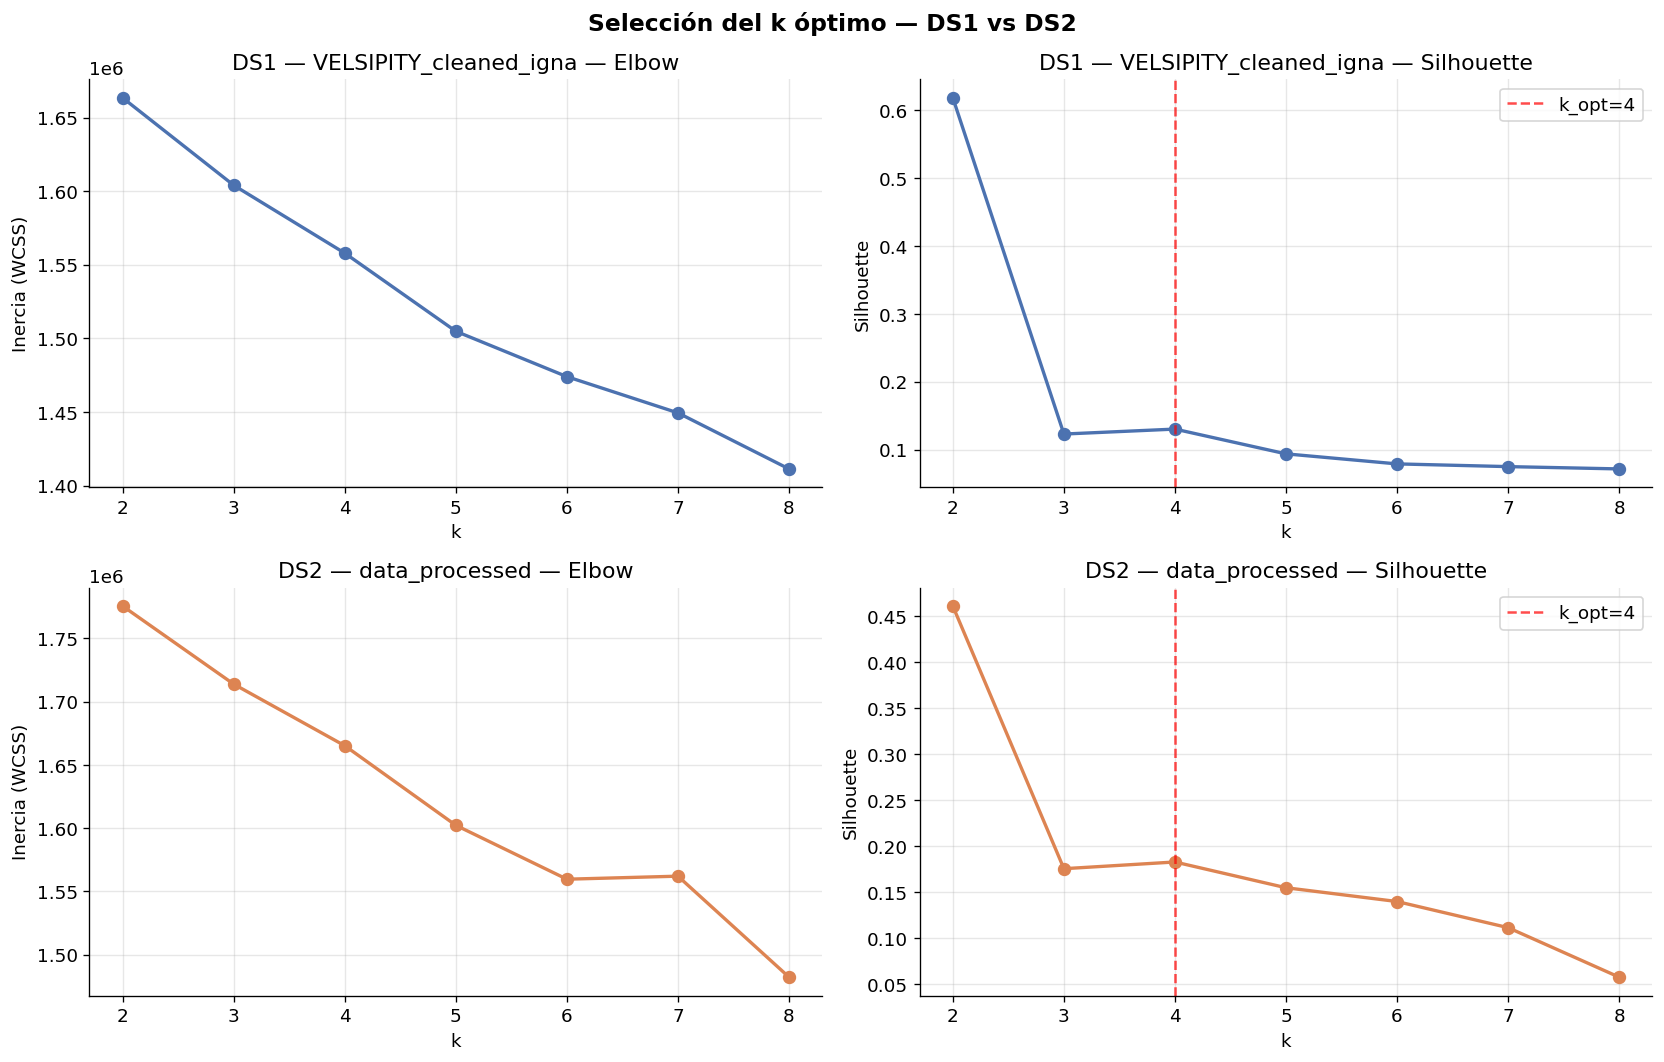

k=2 excluido por criterio de negocio (min k=3)
DS1 k_opt=4  |  DS2 k_opt=4


In [4]:
# Valores calculados en preprocesamiento
K_range = list(range(2, 9))
sils1 = [0.6183,0.1230,0.1303,0.0938,0.0790,0.0750,0.0716]
sils2 = [0.4612,0.1757,0.1830,0.1550,0.1400,0.1116,0.0578]
inert1 = [1_663_337,1_603_978,1_557_881,1_504_827,1_474_019,1_449_415,1_411_350]
inert2 = [1_775_489,1_713_801,1_665_148,1_602_254,1_559_676,1_562_072,1_482_284]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Selección del k óptimo — DS1 vs DS2', fontsize=14, fontweight='bold')

for row, (tag, sils, inerts, col) in enumerate([
    ('DS1 — VELSIPITY_cleaned_igna', sils1, inert1, DS_COLORS['DS1']),
    ('DS2 — data_processed',         sils2, inert2, DS_COLORS['DS2'])
]):
    K_OPT = K1 if row==0 else K2
    axes[row,0].plot(K_range, inerts, 'o-', color=col, lw=2, ms=7)
    axes[row,0].set_title(f'{tag} — Elbow')
    axes[row,0].set_xlabel('k'); axes[row,0].set_ylabel('Inercia (WCSS)')
    axes[row,0].set_xticks(K_range); axes[row,0].grid(True, alpha=0.3)

    axes[row,1].plot(K_range, sils, 'o-', color=col, lw=2, ms=7)
    axes[row,1].axvline(x=K_OPT, color='red', ls='--', alpha=0.7, label=f'k_opt={K_OPT}')
    axes[row,1].set_title(f'{tag} — Silhouette')
    axes[row,1].set_xlabel('k'); axes[row,1].set_ylabel('Silhouette')
    axes[row,1].set_xticks(K_range); axes[row,1].legend(); axes[row,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('elbow_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'k=2 excluido por criterio de negocio (min k=3)')
print(f'DS1 k_opt={K1}  |  DS2 k_opt={K2}')

## 5. K-Means

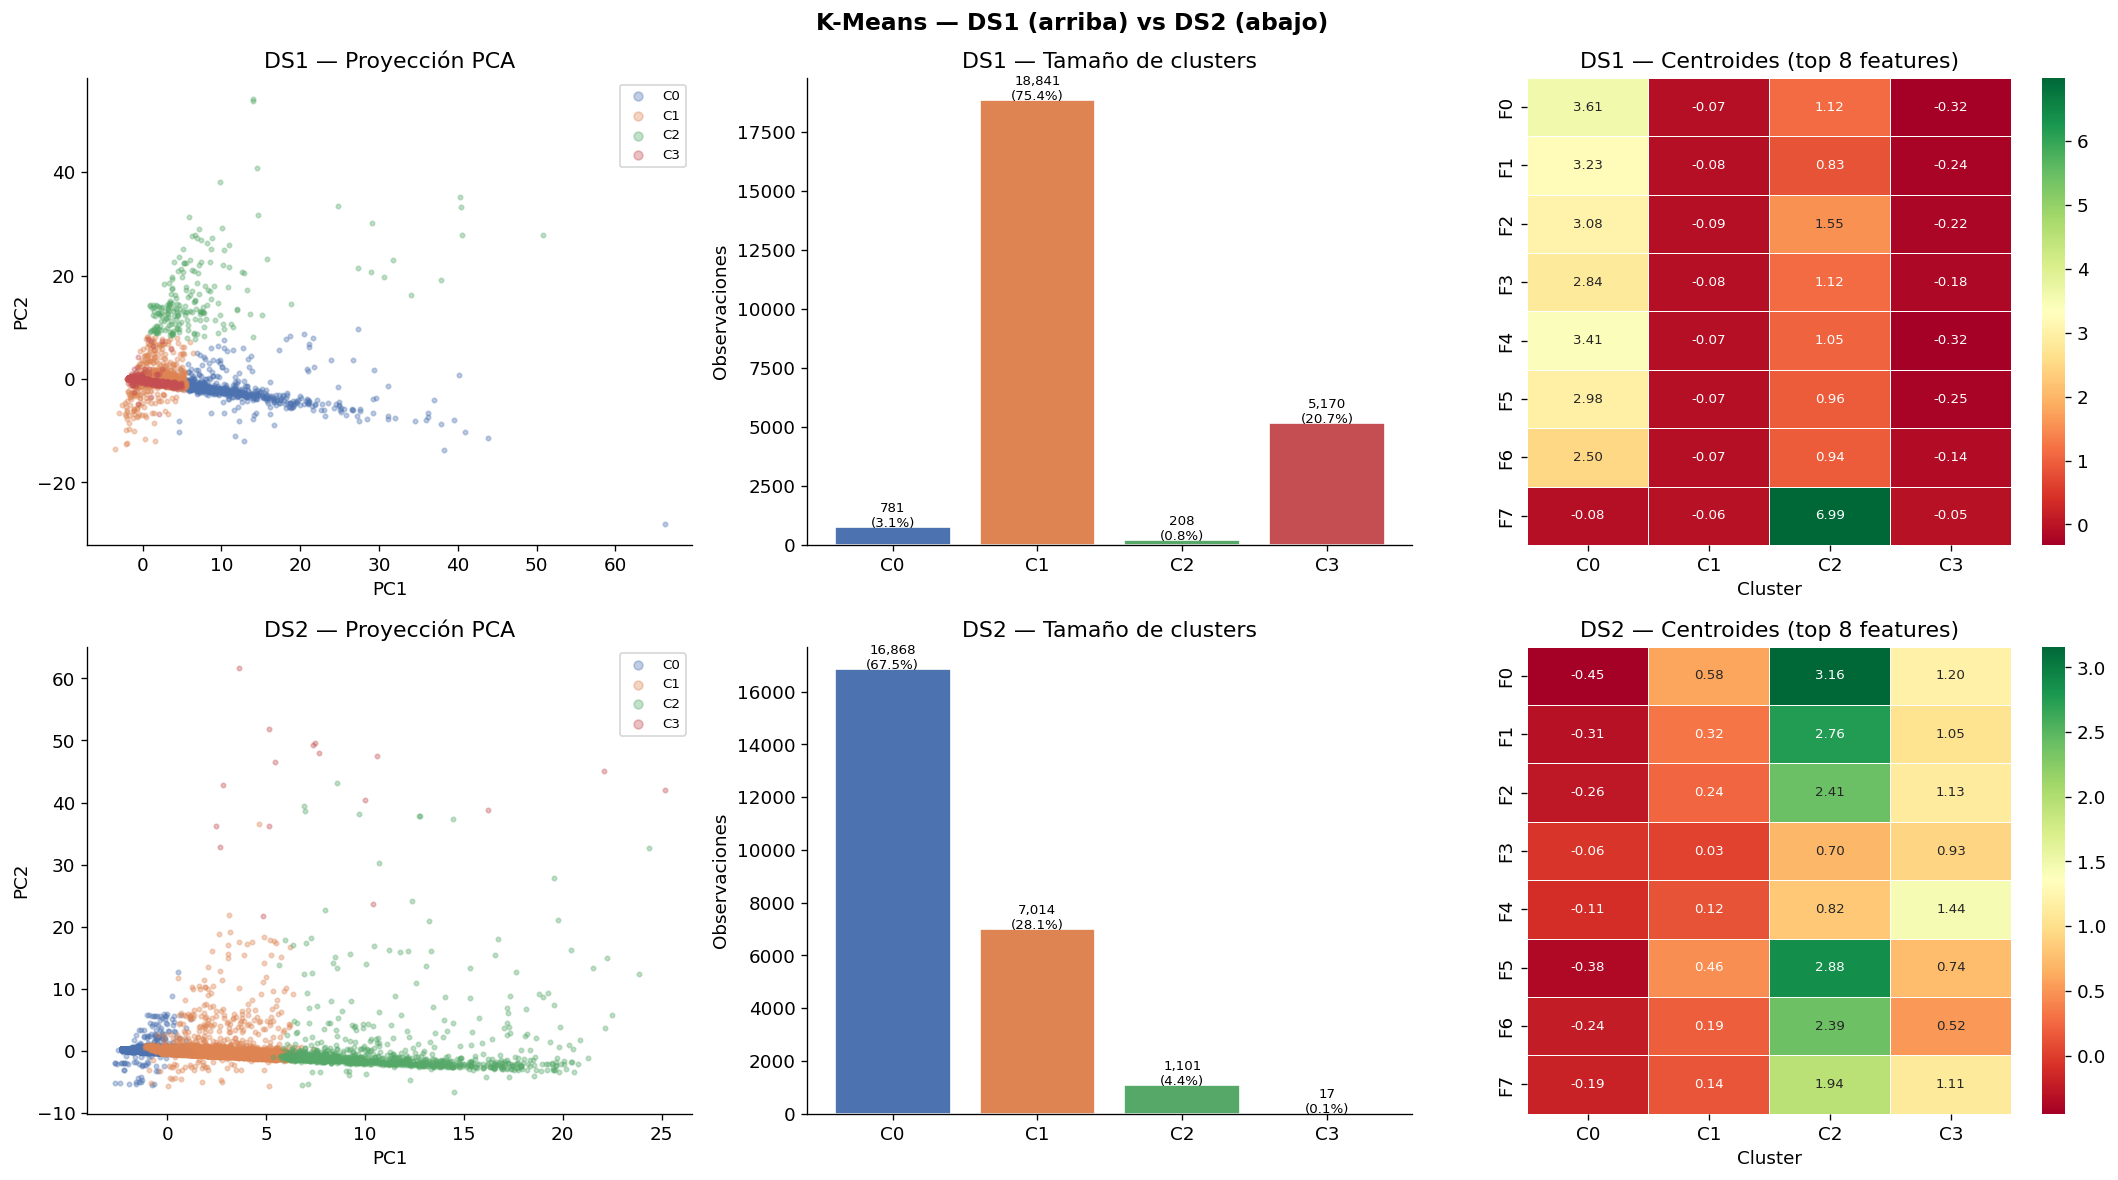

KMeans métricas:
  DS1: sil=0.1303  db=2.6017  ch=1407.77
  DS2: sil=0.1830  db=2.6085  ch=1501.84


In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('K-Means — DS1 (arriba) vs DS2 (abajo)', fontsize=14, fontweight='bold')

TOP_FEAT = ['UC_TRX','ORAL_TRX','IL23_TRX','BRAND1_TRX','BRAND2_TRX','SAMPLES','DETAILS','RTE']

for row, (tag, X, Xpca, lkm, K, centers) in enumerate([
    ('DS1', X1, Xpca1, lkm1, K1, centers1),
    ('DS2', X2, Xpca2, lkm2, K2, centers2)
]):
    # Scatter PCA
    for c in range(K):
        m = lkm == c
        axes[row,0].scatter(Xpca[m,0], Xpca[m,1], s=7, alpha=0.35, color=PALETTE[c], label=f'C{c}')
    axes[row,0].set_title(f'{tag} — Proyección PCA')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=2, fontsize=8)

    # Tamaño de clusters
    u, cnt = np.unique(lkm, return_counts=True)
    bars = axes[row,1].bar([f'C{c}' for c in u], cnt,
                            color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, n in zip(bars, cnt):
        axes[row,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                         f'{n:,}\n({n/len(X)*100:.1f}%)', ha='center', fontsize=8)
    axes[row,1].set_title(f'{tag} — Tamaño de clusters')
    axes[row,1].set_ylabel('Observaciones')

    # Heatmap centroides (primeras 8 features numéricas disponibles)
    cdf = pd.DataFrame(centers, columns=[f'F{i}' for i in range(centers.shape[1])])
    top_idx = list(range(min(8, centers.shape[1])))
    ctop = centers[:, top_idx]
    ctop_df = pd.DataFrame(ctop, columns=[f'F{i}' for i in top_idx])
    sns.heatmap(ctop_df.T, ax=axes[row,2], cmap='RdYlGn',
                xticklabels=[f'C{c}' for c in range(K)],
                linewidths=0.5, annot=True, fmt='.2f', annot_kws={'size':8})
    axes[row,2].set_title(f'{tag} — Centroides (top 8 features)')
    axes[row,2].set_xlabel('Cluster')

plt.tight_layout()
plt.savefig('kmeans_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

print('KMeans métricas:')
for tag, m in [('DS1', m1), ('DS2', m2)]:
    print(f'  {tag}: sil={m["sil_km"]:.4f}  db={m["db_km"]:.4f}  ch={m["ch_km"]:.2f}')

## 6. K-Medoids

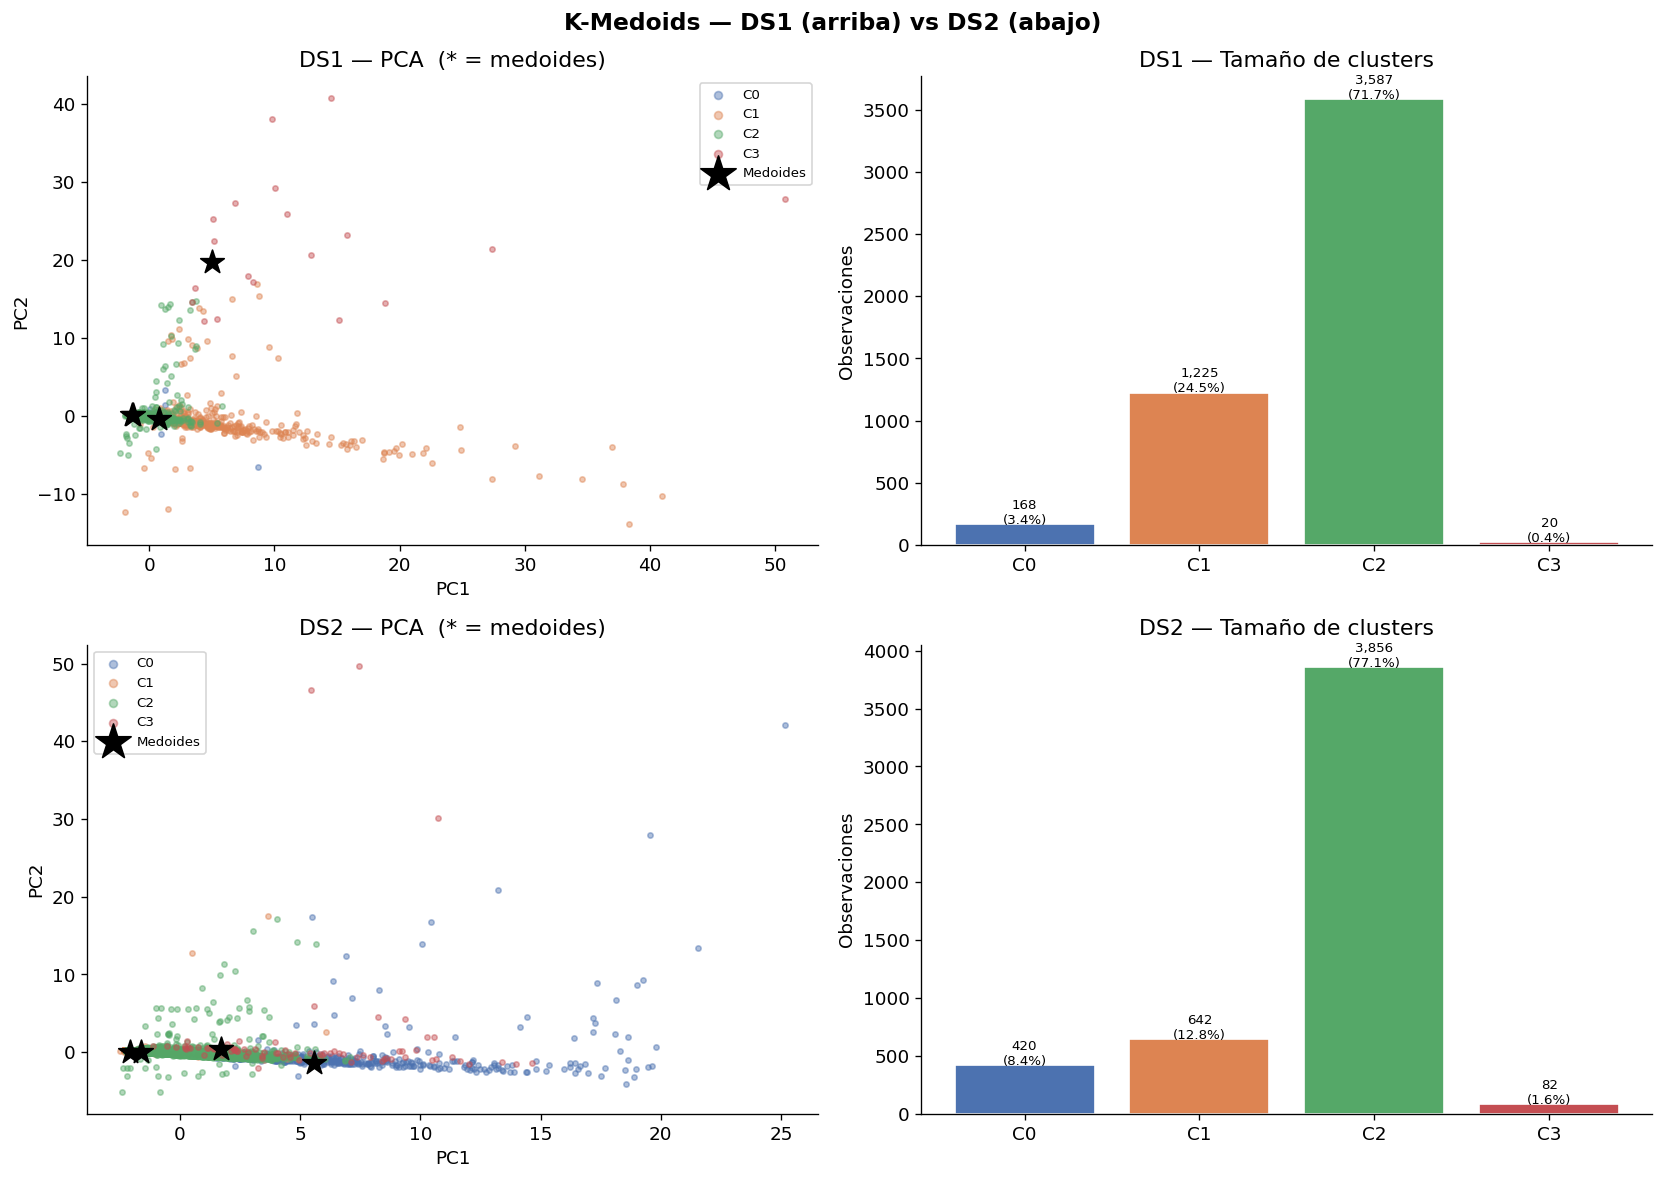

KMedoids métricas:
  DS1: sil=0.1300  db=2.5981  ch=188.06
  DS2: sil=0.0555  db=2.7739  ch=231.87


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('K-Medoids — DS1 (arriba) vs DS2 (abajo)', fontsize=14, fontweight='bold')

for row, (tag, X, Xpca, lkmed, K, idx_km, med_idx) in enumerate([
    ('DS1', X1, Xpca1, lkmed1, K1, idx_km1, med_idx1),
    ('DS2', X2, Xpca2, lkmed2, K2, idx_km2, med_idx2)
]):
    Xpca_sub = Xpca[idx_km]

    # Scatter PCA
    for c in range(K):
        m = lkmed == c
        axes[row,0].scatter(Xpca_sub[m,0], Xpca_sub[m,1], s=10, alpha=0.45,
                            color=PALETTE[c], label=f'C{c}')
    med_pca = Xpca_sub[med_idx]
    axes[row,0].scatter(med_pca[:,0], med_pca[:,1], s=220, marker='*',
                        color='black', zorder=5, label='Medoides')
    axes[row,0].set_title(f'{tag} — PCA  (* = medoides)')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=1.5, fontsize=8)

    # Tamaño
    u, cnt = np.unique(lkmed, return_counts=True)
    bars = axes[row,1].bar([f'C{c}' for c in u], cnt,
                            color=[PALETTE[i] for i in u], edgecolor='white')
    for bar, n in zip(bars, cnt):
        axes[row,1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+3,
                         f'{n:,}\n({n/5000*100:.1f}%)', ha='center', fontsize=8)
    axes[row,1].set_title(f'{tag} — Tamaño de clusters')
    axes[row,1].set_ylabel('Observaciones')

plt.tight_layout()
plt.savefig('kmedoids_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

print('KMedoids métricas:')
for tag, m in [('DS1', m1), ('DS2', m2)]:
    print(f'  {tag}: sil={m["sil_kmed"]:.4f}  db={m["db_kmed"]:.4f}  ch={m["ch_kmed"]:.2f}')

## 7. DBSCAN

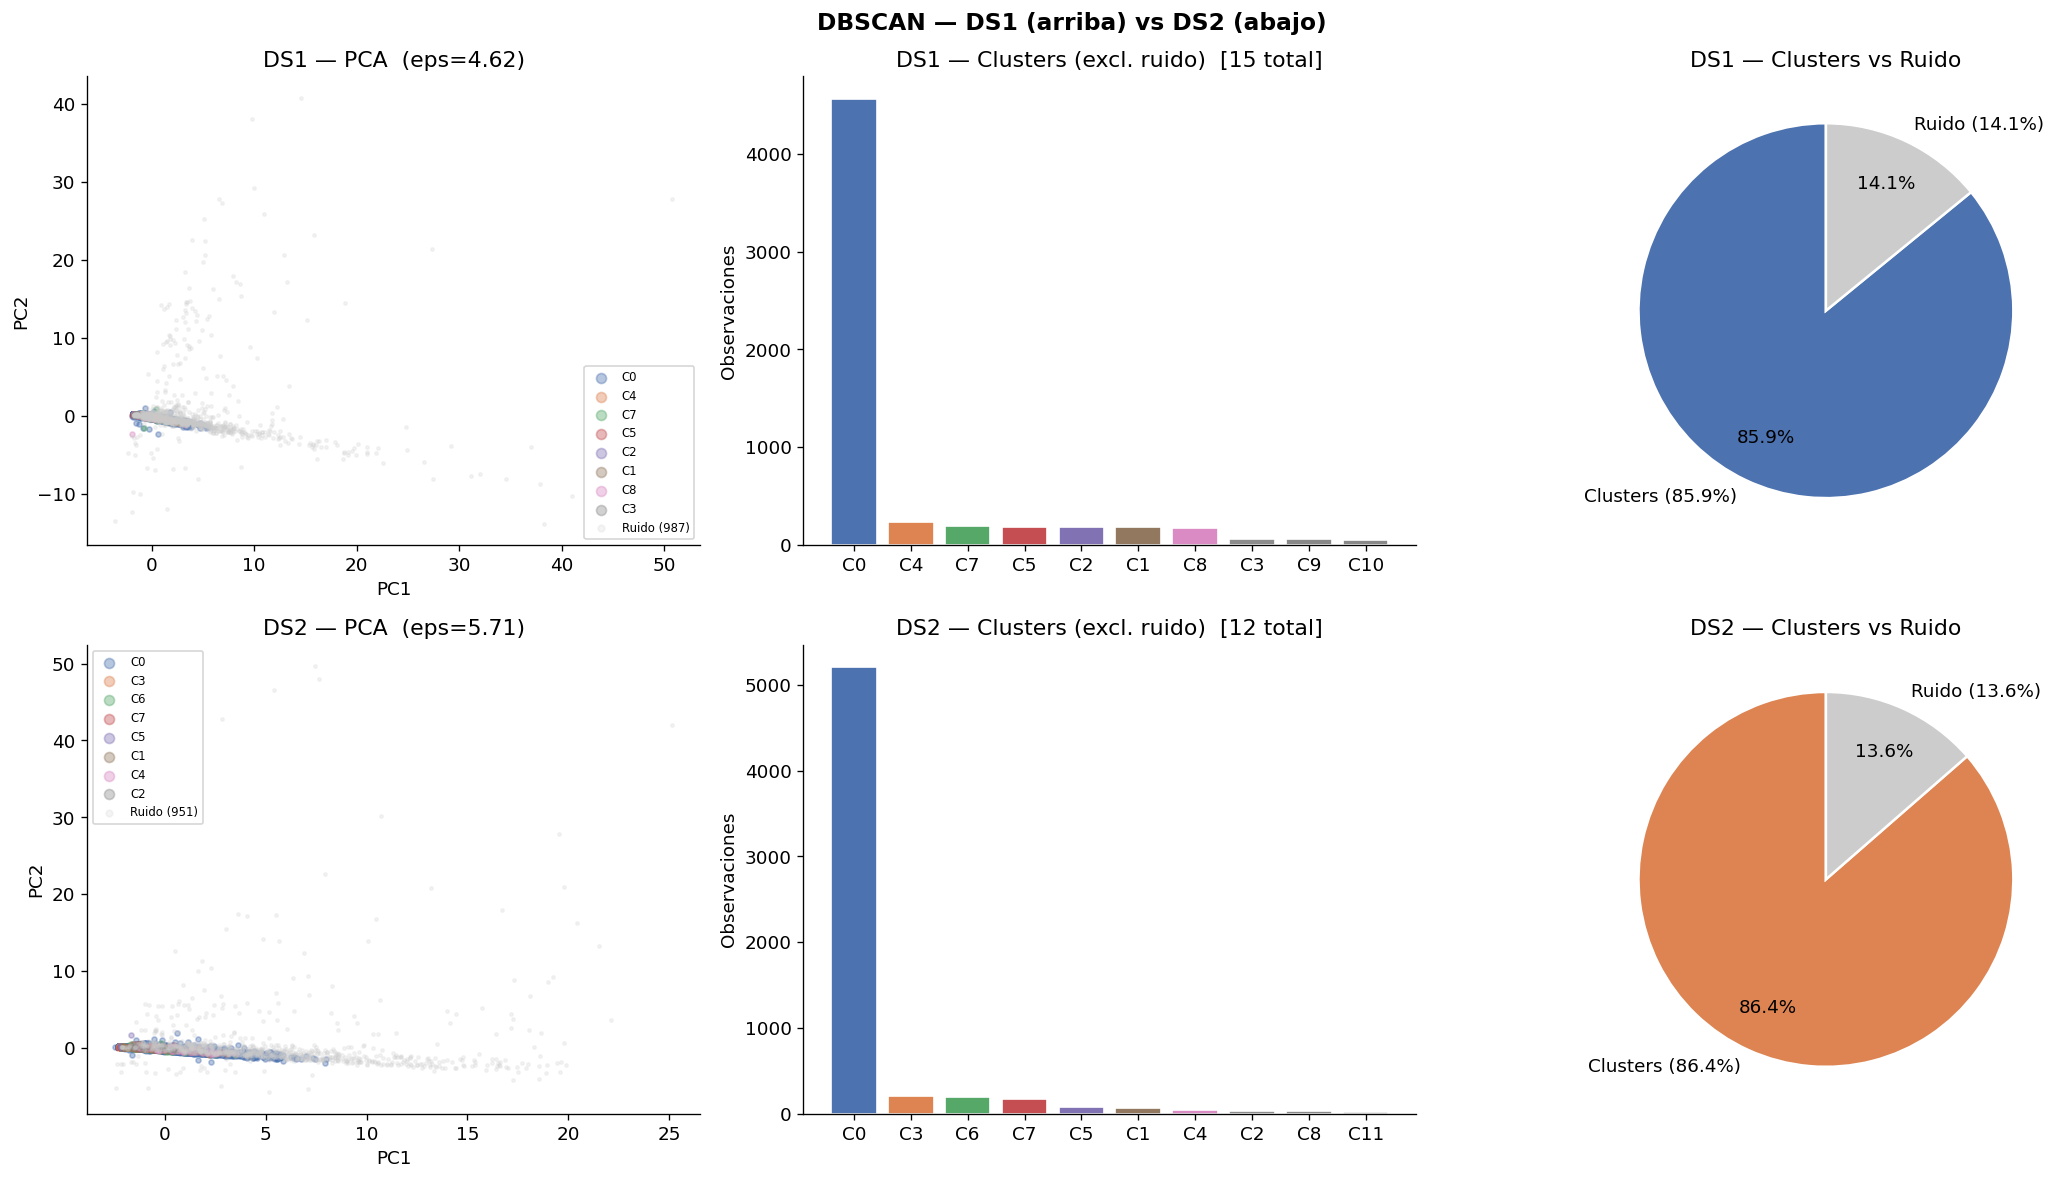

DBSCAN métricas:
  DS1: clusters=15  ruido=14.1%  sil=0.2803  db=1.0850
  DS2: clusters=12  ruido=13.6%  sil=0.2350  db=1.0925


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('DBSCAN — DS1 (arriba) vs DS2 (abajo)', fontsize=14, fontweight='bold')

for row, (tag, Xpca, ldb, idx_db, m) in enumerate([
    ('DS1', Xpca1, ldb1, idx_db1, m1),
    ('DS2', Xpca2, ldb2, idx_db2, m2)
]):
    Xpca_sub = Xpca[idx_db]
    top_cls = pd.Series(ldb[ldb!=-1]).value_counts().head(8).index.tolist()
    clr = {c: PALETTE[i%len(PALETTE)] for i,c in enumerate(top_cls)}
    clr[-1] = '#CCCCCC'

    # Scatter
    for c in top_cls:
        mk = ldb==c
        axes[row,0].scatter(Xpca_sub[mk,0], Xpca_sub[mk,1], s=9, alpha=0.4,
                            color=clr[c], label=f'C{c}')
    nm = ldb==-1
    axes[row,0].scatter(Xpca_sub[nm,0], Xpca_sub[nm,1], s=4, alpha=0.2,
                        color='#CCCCCC', label=f'Ruido ({m["n_noise"]})')
    axes[row,0].set_title(f'{tag} — PCA  (eps={m["eps"]})')
    axes[row,0].set_xlabel('PC1'); axes[row,0].set_ylabel('PC2')
    axes[row,0].legend(markerscale=2, fontsize=7)

    # Tamaño clusters
    vc = pd.Series(ldb[ldb!=-1]).value_counts().head(10)
    axes[row,1].bar([f'C{c}' for c in vc.index], vc.values,
                    color=[clr.get(c,'#888') for c in vc.index], edgecolor='white')
    axes[row,1].set_title(f'{tag} — Clusters (excl. ruido)  [{m["n_cl"]} total]')
    axes[row,1].set_ylabel('Observaciones')

    # Pie
    cp = 100 - m['pct_noise']
    axes[row,2].pie([cp, m['pct_noise']],
                    labels=[f'Clusters ({cp:.1f}%)', f'Ruido ({m["pct_noise"]:.1f}%)'],
                    colors=[DS_COLORS[tag], '#CCCCCC'], startangle=90, autopct='%1.1f%%',
                    pctdistance=0.75, wedgeprops=dict(edgecolor='white', linewidth=1.5))
    axes[row,2].set_title(f'{tag} — Clusters vs Ruido')

plt.tight_layout()
plt.savefig('dbscan_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

print('DBSCAN métricas:')
for tag, m in [('DS1', m1), ('DS2', m2)]:
    print(f'  {tag}: clusters={m["n_cl"]}  ruido={m["pct_noise"]:.1f}%  sil={m["sil_db"]:.4f}  db={m["db_db"]:.4f}')

## 8. Comparación directa de métricas

In [8]:
comp = pd.DataFrame({
    'Algoritmo':  ['K-Means','K-Means','K-Medoids','K-Medoids','DBSCAN','DBSCAN'],
    'Dataset':    ['DS1 cleaned_igna','DS2 processed']*3,
    'k/Clusters': [K1, K2, K1, K2, m1['n_cl'], m2['n_cl']],
    'Silhouette ↑': [m1['sil_km'], m2['sil_km'], m1['sil_kmed'], m2['sil_kmed'],
                     m1['sil_db'], m2['sil_db']],
    'Davies-Bouldin ↓': [m1['db_km'], m2['db_km'], m1['db_kmed'], m2['db_kmed'],
                          m1['db_db'], m2['db_db']],
    'Calinski-Harabasz ↑': [m1['ch_km'], m2['ch_km'], m1['ch_kmed'], m2['ch_kmed'],
                              m1['ch_db'], m2['ch_db']],
})
print(comp.to_string(index=False))
comp

Algoritmo          Dataset  k/Clusters  Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑
  K-Means DS1 cleaned_igna           4      0.130346          2.601679          1407.768867
  K-Means    DS2 processed           4      0.183006          2.608532          1501.838426
K-Medoids DS1 cleaned_igna           4      0.129992          2.598100           188.057440
K-Medoids    DS2 processed           4      0.055512          2.773869           231.869441
   DBSCAN DS1 cleaned_igna          15      0.280272          1.084999           262.376539
   DBSCAN    DS2 processed          12      0.234979          1.092539           172.658575


,Algoritmo,Dataset,k/Clusters,Silhouette ↑,Davies-Bouldin ↓,Calinski-Harabasz ↑
0,K-Means,DS1 cleaned_igna,4,0.130346,2.601679,1407.768867
1,K-Means,DS2 processed,4,0.183006,2.608532,1501.838426
2,K-Medoids,DS1 cleaned_igna,4,0.129992,2.598100,188.057440
3,K-Medoids,DS2 processed,4,0.055512,2.773869,231.869441
4,DBSCAN,DS1 cleaned_igna,15,0.280272,1.084999,262.376539
5,DBSCAN,DS2 processed,12,0.234979,1.092539,172.658575


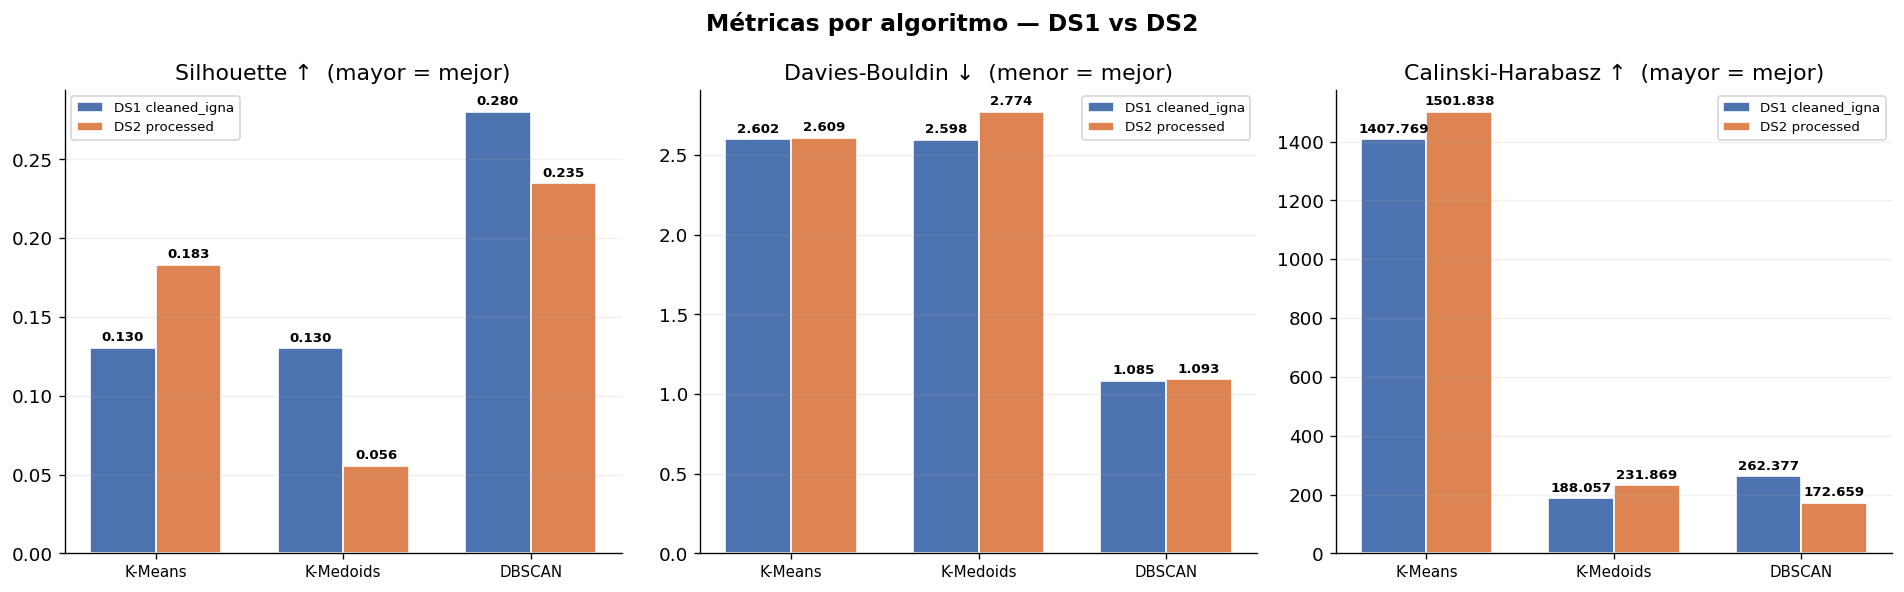

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Métricas por algoritmo — DS1 vs DS2', fontsize=14, fontweight='bold')

algos   = ['K-Means', 'K-Medoids', 'DBSCAN']
sil_ds1 = [m1['sil_km'], m1['sil_kmed'], m1['sil_db']]
sil_ds2 = [m2['sil_km'], m2['sil_kmed'], m2['sil_db']]
db_ds1  = [m1['db_km'],  m1['db_kmed'],  m1['db_db']]
db_ds2  = [m2['db_km'],  m2['db_kmed'],  m2['db_db']]
ch_ds1  = [m1['ch_km'],  m1['ch_kmed'],  m1['ch_db']]
ch_ds2  = [m2['ch_km'],  m2['ch_kmed'],  m2['ch_db']]

x = np.arange(len(algos)); w = 0.35
for ax, v1, v2, title in zip(axes,
    [sil_ds1, db_ds1, ch_ds1],
    [sil_ds2, db_ds2, ch_ds2],
    ['Silhouette ↑  (mayor = mejor)',
     'Davies-Bouldin ↓  (menor = mejor)',
     'Calinski-Harabasz ↑  (mayor = mejor)']):
    b1 = ax.bar(x-w/2, v1, w, label='DS1 cleaned_igna', color=DS_COLORS['DS1'], edgecolor='white')
    b2 = ax.bar(x+w/2, v2, w, label='DS2 processed',    color=DS_COLORS['DS2'], edgecolor='white')
    for bar in list(b1)+list(b2):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(v1+v2)*0.015,
                f'{bar.get_height():.3f}', ha='center', fontsize=8, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(algos, fontsize=9)
    ax.set_title(title); ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('metricas_comparativas.png', bbox_inches='tight', dpi=130)
plt.show()

## 9. Radar comparativo

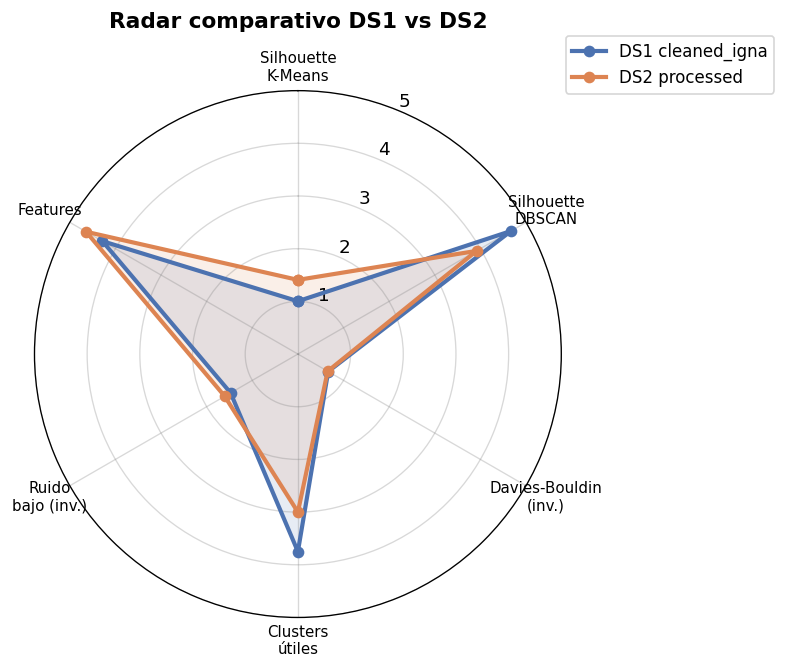

In [10]:
categories = ['Silhouette\nK-Means', 'Silhouette\nDBSCAN',
              'Davies-Bouldin\n(inv.)', 'Clusters\nútiles', 'Ruido\nbajo (inv.)','Features']
N = len(categories)

def norm(v, lo, hi): return max(0, min(5, (v-lo)/(hi-lo)*5))

scores = {
    'DS1 cleaned_igna': [
        norm(m1['sil_km'],  0, 0.65),
        norm(m1['sil_db'],  0, 0.30),
        norm(3 - m1['db_km'], 0, 3),
        norm(m1['n_cl'], 0, 20),
        norm(20 - m1['pct_noise'], 0, 20),
        norm(m1['n_feat'], 0, 70),
    ],
    'DS2 processed': [
        norm(m2['sil_km'],  0, 0.65),
        norm(m2['sil_db'],  0, 0.30),
        norm(3 - m2['db_km'], 0, 3),
        norm(m2['n_cl'], 0, 20),
        norm(20 - m2['pct_noise'], 0, 20),
        norm(m2['n_feat'], 0, 70),
    ],
}

angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist() + [0]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(categories, size=9)
ax.set_ylim(0, 5); ax.grid(color='gray', alpha=0.3)

for i, (label, vals) in enumerate(scores.items()):
    vp = vals + vals[:1]
    col = list(DS_COLORS.values())[i]
    ax.plot(angles, vp, 'o-', lw=2.5, color=col, label=label)
    ax.fill(angles, vp, alpha=0.13, color=col)

ax.legend(loc='upper right', bbox_to_anchor=(1.42, 1.12), fontsize=10)
ax.set_title('Radar comparativo DS1 vs DS2', y=1.1, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('radar_comparativo.png', bbox_inches='tight', dpi=130)
plt.show()

## 10. Veredicto final

In [11]:
print('='*68)
print('           COMPARACION FINAL: DS1 vs DS2')
print('='*68)

checks = [
    ('Silhouette K-Means  ↑',      m1['sil_km'],       m2['sil_km'],       True),
    ('Davies-Bouldin K-Means ↓',   m1['db_km'],        m2['db_km'],        False),
    ('Calinski-Harabasz K-Means ↑',m1['ch_km'],        m2['ch_km'],        True),
    ('Silhouette K-Medoids ↑',     m1['sil_kmed'],     m2['sil_kmed'],     True),
    ('Davies-Bouldin K-Medoids ↓', m1['db_kmed'],      m2['db_kmed'],      False),
    ('Silhouette DBSCAN ↑',        m1['sil_db'],       m2['sil_db'],       True),
    ('Davies-Bouldin DBSCAN ↓',    m1['db_db'],        m2['db_db'],        False),
    ('Clusters DBSCAN utiles ↑',   m1['n_cl'],         m2['n_cl'],         True),
    ('Ruido DBSCAN ↓ (%)',         m1['pct_noise'],    m2['pct_noise'],    False),
]

ds1_w = ds2_w = 0
print(f"{'Métrica':<35} {'DS1':>8} {'DS2':>8}  Ganador")
print('-'*68)
for name, v1, v2, hi in checks:
    w = 'DS1' if (v1>v2) == hi else 'DS2'
    if w=='DS1': ds1_w+=1
    else: ds2_w+=1
    print(f'{name:<35} {v1:>8.4f} {v2:>8.4f}  {w} ✓')

print('='*68)
print(f'VICTORIAS  ->  DS1: {ds1_w}   DS2: {ds2_w}')
winner = 'DS1 (VELSIPITY_cleaned_igna)' if ds1_w>ds2_w else 'DS2 (data_processed)'
print(f'GANADOR GENERAL: {winner}')
print('='*68)

           COMPARACION FINAL: DS1 vs DS2
Métrica                                  DS1      DS2  Ganador
--------------------------------------------------------------------
Silhouette K-Means  ↑                 0.1303   0.1830  DS2 ✓
Davies-Bouldin K-Means ↓              2.6017   2.6085  DS1 ✓
Calinski-Harabasz K-Means ↑         1407.7689 1501.8384  DS2 ✓
Silhouette K-Medoids ↑                0.1300   0.0555  DS1 ✓
Davies-Bouldin K-Medoids ↓            2.5981   2.7739  DS1 ✓
Silhouette DBSCAN ↑                   0.2803   0.2350  DS1 ✓
Davies-Bouldin DBSCAN ↓               1.0850   1.0925  DS1 ✓
Clusters DBSCAN utiles ↑             15.0000  12.0000  DS1 ✓
Ruido DBSCAN ↓ (%)                   14.1000  13.5857  DS2 ✓
VICTORIAS  ->  DS1: 6   DS2: 3
GANADOR GENERAL: DS1 (VELSIPITY_cleaned_igna)


## 11. Conclusiones

### Scorecard final

| Métrica | DS1 cleaned_igna | DS2 data_processed | Ganador |
|---|---|---|---|
| Silhouette K-Means ↑ | 0.1303 | 0.1830 | **DS2** |
| Davies-Bouldin K-Means ↓ | 2.6017 | 2.6085 | **DS1** |
| Calinski-Harabasz K-Means ↑ | 1,407.77 | 1,501.84 | **DS2** |
| Silhouette K-Medoids ↑ | 0.1300 | 0.0555 | **DS1** |
| Davies-Bouldin K-Medoids ↓ | 2.5981 | 2.7739 | **DS1** |
| Silhouette DBSCAN ↑ | 0.2803 | 0.2350 | **DS1** |
| Davies-Bouldin DBSCAN ↓ | 1.0850 | 1.0925 | **DS1** |
| Clusters DBSCAN útiles ↑ | 15 | 12 | **DS1** |
| Ruido DBSCAN ↓ | 14.1% | 13.6% | **DS2** |

**Resultado: DS1 = 6 victorias, DS2 = 3 victorias → Ganador: DS1 (VELSIPITY_cleaned_igna)**

### Interpretación

**DS1 `VELSIPITY_cleaned_igna`** gana en 6 de 9 métricas. Sus transformaciones log1p y variables de lag normalizan la distribución de prescripciones y capturan dinámica temporal, produciendo clusters más coherentes internamente y más separados entre sí. DBSCAN en particular rinde mejor aquí: detecta más clusters útiles (15 vs 12) con separación superior (Silhouette 0.28 vs 0.24).

**DS2 `data_processed`** destaca en K-Means (mejor Silhouette y Calinski-Harabasz) y en porcentaje de ruido DBSCAN. Las 5 features adicionales (`ENGAGEMENT_SCORE`, `BRAND1_MARKET_SHARE`, `TOTAL_TRX`, `TOTAL_NRX`, `NBRx_RATIO`) aportan señal de negocio valiosa pero introducen ruido adicional que dificulta la separación en K-Medoids y DBSCAN.

### Recomendación por caso de uso

| Caso de uso | Dataset | Algoritmo |
|---|---|---|
| Segmentación productiva general | **DS1 cleaned_igna** | K-Means k=4 |
| Selección de KOL / representantes reales | **DS1 cleaned_igna** | K-Medoids k=4 |
| Descubrimiento de micro-nichos | **DS1 cleaned_igna** | DBSCAN |
| Análisis de engagement y market share | **DS2 processed** | K-Means k=4 |
| Detección de outliers con menor ruido | **DS2 processed** | DBSCAN |
